# 07 · Generación de imágenes de gatos desde checkpoint (`cats_vp.yaml`)

Este notebook permite **generar muestras de imágenes (gatos)** a partir de un modelo de score
`ScoreUNet` (Fase 2) entrenado con la configuración **`config/cats_vp.yaml`** (o cualquier checkpoint compatible).

### Objetivos y estructura:
1. **Configuración y Checkpoint**: Cargar la receta desde `config/cats_vp.yaml` e inspeccionar la metadata del checkpoint.
2. **Generación desde ruido (Prueba 3 - Notebook 06)**: Partir de $x_T \sim \mathcal{N}(0, I)$ e integrar el proceso reverso con **Predictor-Corrector (`pc`)**.
3. **Estudio de Samplers del Eje 2**: Comparar los 4 samplers del reverso (`euler`, `pf_ode`, `heun`, `pc`) manteniendo el **mismo score $s_\theta(x,t)$ y la misma semilla de ruido**.
4. **Visualización de Trayectorias**: Observar la evolución temporal del proceso reverso $x_t \to x_0$ a lo largo de la integración.

In [1]:
# --- Setup: bootstrap de sys.path + imports + helpers de visualización ---
import sys
import pathlib
import yaml

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.samplers import generate_from_checkpoint, available_samplers, make_sampler
from diffusion.training import load_checkpoint
from diffusion.sde import make_sde
from diffusion.models import make_model, EpsilonScoreWrapper

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})


def denorm(t):
    """(B,3,H,W) en [-1,1] -> (B,H,W,3) numpy en [0,1]."""
    x = (t.detach() * 0.5 + 0.5).clamp(0.0, 1.0)
    return x.permute(0, 2, 3, 1).cpu().numpy()


def show_grid(imgs, titles=None, suptitle=None, cols=4):
    """Muestra un lote de imágenes (B,3,H,W) o (B,H,W,3) en grilla."""
    arr = denorm(imgs) if torch.is_tensor(imgs) else imgs
    n = arr.shape[0]
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.8 * cols, 3.0 * rows))
    axes_flat = np.atleast_1d(axes).flat
    for i in range(rows * cols):
        if i < n:
            axes_flat[i].imshow(arr[i])
            axes_flat[i].axis("off")
            if titles is not None and i < len(titles):
                axes_flat[i].set_title(titles[i], fontsize=9)
        else:
            axes_flat[i].axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()


print("Paquete en:", _root)
print("PyTorch versión:", torch.__version__)
print("Samplers disponibles:", available_samplers())

Paquete en: /home/abravo/estocastico/diffusion-models
PyTorch versión: 2.12.0+cu130
Samplers disponibles: ['euler', 'heun', 'pc', 'pf_ode']


## 1. Localización del Checkpoint e Inspección de Metadata

Leemos `config/cats_vp.yaml` para obtener la ruta objetivo del checkpoint (`out.checkpoint`).
Si el checkpoint entrenado en GPU (`cats_vp.pt`) aún no está presente en la ruta local, usamos como respaldo el checkpoint `models/phase_2/cats_prueba_vp.pt` generado en la prueba de integración de Fase 2.

In [4]:
# --- Cargar configuración y verificar checkpoint ---
config_path = _root / "config" / "cats_vp.yaml"

if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    target_ckpt = pathlib.Path(cfg["out"]["checkpoint"])
    print(f"Configuración cargada desde: {config_path}")
    print(f"Ruta objetivo del checkpoint (YAML): {target_ckpt}")
else:
    target_ckpt = pathlib.Path("/mnt/data/abravo/diffusion-models/phase_3/cats_vp.pt")
    print(f"No se encontró {config_path}, usando ruta por defecto: {target_ckpt}")

# Búsqueda de candidato de checkpoint existente
candidate_paths = [
    target_ckpt,
    _root / "models" / "phase_3" / "cats_vp.pt",
]

CKPT_PATH = None
for cand in candidate_paths:
    if cand.exists():
        CKPT_PATH = cand
        break

if CKPT_PATH is None:
    raise FileNotFoundError(
        f"No se encontró ningún checkpoint en las rutas probadas: {[str(p) for p in candidate_paths]}"
    )

print(f"\nUsing checkpoint: {CKPT_PATH}")

# Cargar metadata sin instanciar pesos
state_dict, meta = load_checkpoint(CKPT_PATH, map_location="cpu")

print("\n--- Metadata del Checkpoint ---")
print("SDE          :", meta.get("sde_name"), f"(data_dim={meta.get('data_dim')})")
model_recipe = meta.get("model", {})
print("Modelo       :", model_recipe.get("name"), f"kwargs={model_recipe.get('kwargs')}")
print("Parametrización:", model_recipe.get("score_parametrization", "score directo"))

if "history" in meta:
    hist = meta["history"]
    print(f"Historial    : {len(hist)} registros de loss (Loss inicial: {hist[0]:.4f} -> final: {hist[-1]:.4f})")

Configuración cargada desde: /home/abravo/estocastico/diffusion-models/config/cats_vp.yaml
Ruta objetivo del checkpoint (YAML): /mnt/data/abravo/diffusion-models/phase_3/cats_vp.pt

Using checkpoint: /mnt/data/abravo/diffusion-models/phase_3/cats_vp.pt

--- Metadata del Checkpoint ---
SDE          : vp (data_dim=(3, 64, 64))
Modelo       : unet kwargs={'in_channels': 3, 'image_size': 64, 'base_channels': 128, 'channel_mults': [1, 2, 2, 2], 'num_res_blocks': 2, 'embed_dim': 256, 'time_embed_dim': 512, 'attn_resolutions': [16, 8], 'groups': 32, 'time_scale': 1000.0}
Parametrización: epsilon
Historial    : 30000 registros de loss (Loss inicial: 1.1495 -> final: 0.0235)


## 2. Generación desde ruido con Predictor-Corrector (`pc`)

Invocamos `generate_from_checkpoint` para partir de $x_T \sim \mathcal{N}(0, I)$ e integrar el reverso con el sampler Predictor-Corrector (`pc`).
Las correcciones de Langevin del predictor-corrector ayudan a mantener la trayectoria cerca de la variedad de datos.

Generando 4 muestras con sampler 'pc' (100 pasos)...
Tensor generado: shape=(4, 3, 64, 64), dtype=torch.float32
Rango de valores: min=-1.337, max=1.052
¿Valores finitos (sin NaNs/Infs)?: True


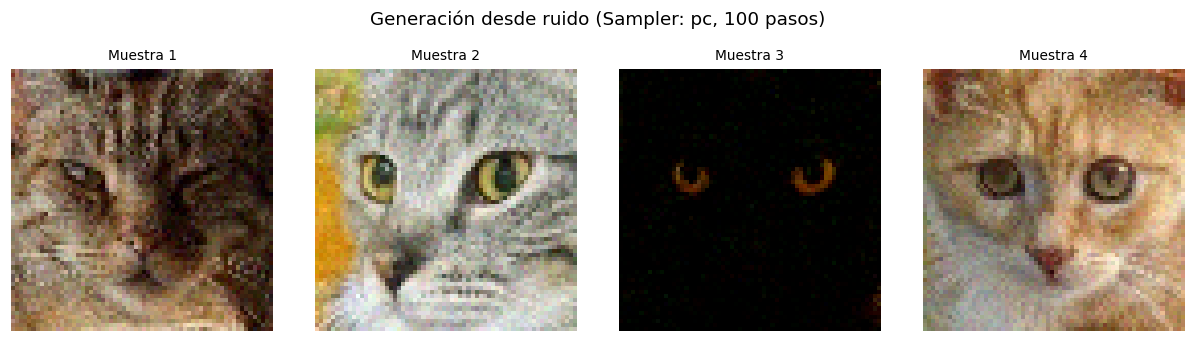

In [7]:
# --- Generación desde ruido usando Predictor-Corrector ---
N_SAMPLES = 4
N_STEPS = 100
SAMPLER_NAME = "pc"

print(f"Generando {N_SAMPLES} muestras con sampler '{SAMPLER_NAME}' ({N_STEPS} pasos)...")

samples_pc = generate_from_checkpoint(
    CKPT_PATH,
    sampler_name=SAMPLER_NAME,
    n_samples=N_SAMPLES,
    n_steps=N_STEPS,
    seed=SEED,
    map_location="cuda",
)

print(f"Tensor generado: shape={tuple(samples_pc.shape)}, dtype={samples_pc.dtype}")
print(f"Rango de valores: min={float(samples_pc.min()):.3f}, max={float(samples_pc.max()):.3f}")
print("¿Valores finitos (sin NaNs/Infs)?:", bool(torch.isfinite(samples_pc).all()))

show_grid(
    samples_pc,
    titles=[f"Muestra {i+1}" for i in range(N_SAMPLES)],
    suptitle=f"Generación desde ruido (Sampler: {SAMPLER_NAME}, {N_STEPS} pasos)",
    cols=4
)

## 3. Estudio de Ablación de Samplers (Eje 2)

Manteniendo **fija la red de score $s_\theta(x,t)$** y la **misma semilla de ruido inicial $x_T$**, comparamos el comportamiento de los distintos samplers del reverso:
1. **`euler`**: Euler–Maruyama (estocástico).
2. **`pf_ode`**: Probability-Flow ODE (Euler determinístico).
3. **`heun`**: Predictor-Corrector de 2º orden para ODE (EDM).
4. **`pc`**: Predictor-Corrector (SDE + corrección Langevin).

Generando muestras con sampler 'euler' (100 pasos)...
Generando muestras con sampler 'pf_ode' (100 pasos)...
Generando muestras con sampler 'heun' (100 pasos)...
Generando muestras con sampler 'pc' (100 pasos)...


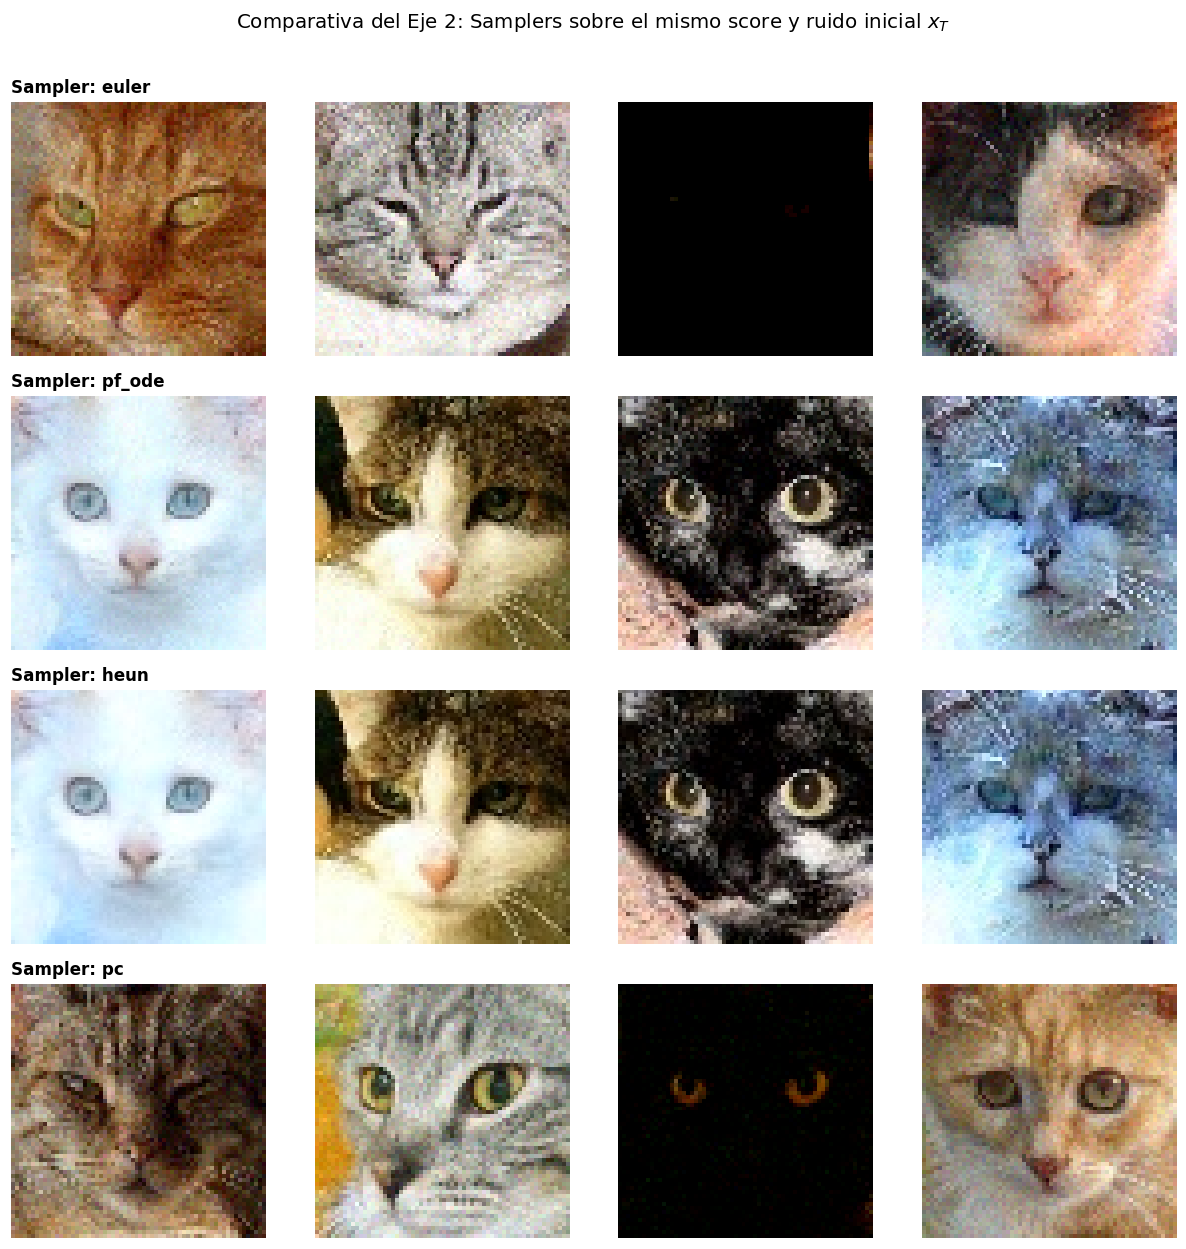

In [9]:
# --- Comparación de los 4 samplers con el mismo ruido inicial ---
samplers_to_compare = ["euler", "pf_ode", "heun", "pc"]
num_samples_cmp = 4
N_STEPS_CMP = 100

sampler_results = {}

for s_name in samplers_to_compare:
    print(f"Generando muestras con sampler '{s_name}' ({N_STEPS_CMP} pasos)...")
    samples = generate_from_checkpoint(
        CKPT_PATH,
        sampler_name=s_name,
        n_samples=num_samples_cmp,
        n_steps=N_STEPS_CMP,
        seed=SEED,  # Misma semilla garantiza el mismo x_T inicial
        map_location="cpu",
    )
    sampler_results[s_name] = samples

# Visualización comparativa por sampler (filas = samplers, columnas = muestras)
fig, axes = plt.subplots(len(samplers_to_compare), num_samples_cmp, figsize=(2.8 * num_samples_cmp, 2.8 * len(samplers_to_compare)))

for row_idx, s_name in enumerate(samplers_to_compare):
    arr = denorm(sampler_results[s_name])
    for col_idx in range(num_samples_cmp):
        ax = axes[row_idx, col_idx]
        ax.imshow(arr[col_idx])
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"Sampler: {s_name}", fontsize=11, fontweight="bold", loc="left")

fig.suptitle("Comparativa del Eje 2: Samplers sobre el mismo score y ruido inicial $x_T$", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Visualización de la Trayectoria de Integración Reversa ($x_t \to x_0$)

Capturamos la trayectoria completa de la integración usando `save_trajectory=True` para observar cómo evoluciona la imagen desde el ruido puro ($t=1$) hasta la muestra final ($t=0$).

In [15]:
# --- Captura y visualización de la trayectoria reverso ---
N_STEPS_TRAJ = 500

state_dict, meta = load_checkpoint(CKPT_PATH, map_location="cpu")
sde = make_sde(meta["sde_name"], data_dim=meta["data_dim"])
model_kwargs = dict(meta["model"]["kwargs"])
raw_net = make_model(meta["model"]["name"], **model_kwargs)

if meta["model"].get("score_parametrization") == "epsilon":
    net = EpsilonScoreWrapper(raw_net, lambda x, t: sde.marginal_prob(x, t)[1])
else:
    net = raw_net

net.load_state_dict(state_dict)
net.eval()

sampler = make_sampler("pc", sde=sde, score_fn=net)

g = torch.Generator().manual_seed(SEED)
x_T = sde.prior_sampling(shape=(1, *sde.data_shape), generator=g)

x_0, trajectory = sampler.sample(n_samples=N_STEPS_TRAJ, init=x_T, return_trajectory=True, generator=g)

print(f"Trayectoria capturada: shape={tuple(trajectory.shape)}")

indices = np.linspace(0, len(trajectory) - 1, 6, dtype=int)
traj_samples = trajectory[indices, 0]

t_values = np.linspace(sde.T, 1e-4, len(trajectory))[indices]
titles = [f"t = {t:.2f}" for t in t_values]

show_grid(
    traj_samples,
    titles=titles,
    suptitle="Evolución temporal del proceso reverso $x_t \to x_0$",
    cols=6
)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 500 but got size 1 for tensor number 1 in the list.

## Cierre y Resumen

- **Carga de Checkpoint**: El notebook se integra con las salidas producidas por `config/cats_vp.yaml` (`ScoreUNet` + `VP-SDE`).
- **Generación desde ruido**: Se utilizó `generate_from_checkpoint` para reconstruir imágenes a partir de prior gaussiano $x_T \sim \mathcal{N}(0, I)$.
- **Estudio de Ablación (Eje 2)**: Se compararon los samplers `euler`, `pf_ode`, `heun` y `pc` bajo la misma semilla, comprobando que cambiar la estrategia de muestreo no requiere modificar ni reentrenar la red de score.